# Flux-Difference Check for NGC4396

This notebook compares the `FLUX` HDU for `NGC4396` using the two spatial-binning FITS files it can find locally.

- It plots the two `FLUX` maps on the common finite-spaxel mask.
- It plots the pixel-wise ratio map.
- It prints the summed flux from the same common finite-spaxel set.

The exact `NGC4396_v3tk_spatial_binning_maps_extended.fits` file is not currently present in this workspace, so the code below falls back to the closest local v3tk-style file if needed and prints the exact paths it used.

Galaxy: NGC4396
v3tk file     : /Users/Igniz/Desktop/ICRAR/extended/SNR200/NGC4396_v3tk_SNR200_spatial_binning_maps_extended.fits
standard file : /Users/Igniz/Desktop/ICRAR/extended/NGC4396_SPATIAL_BINNING_maps_extended.fits
Common finite spaxels       : 155,156
Common valid ratio spaxels  : 155,156
Summed FLUX (v3tk)          : 2.66373588e+06
Summed FLUX (standard)      : 2.66454816e+06
Summed FLUX ratio (v3tk/std): 0.99969515
Median pixel ratio          : 0.99981408


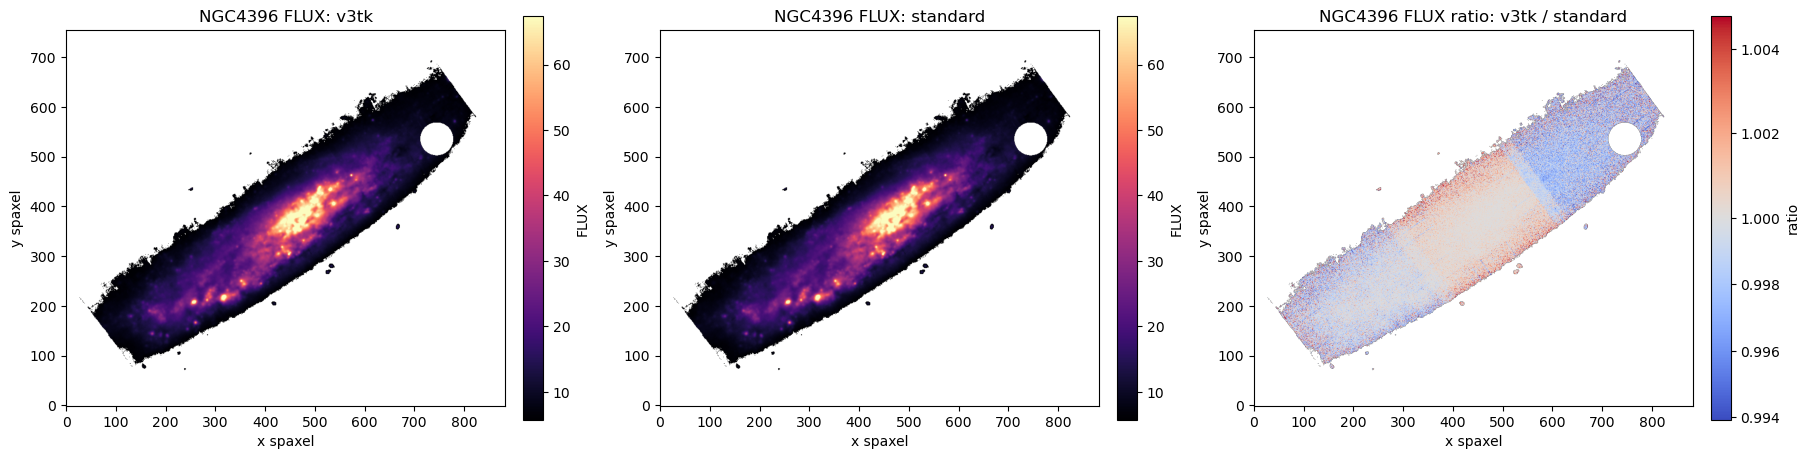

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from matplotlib.colors import TwoSlopeNorm

GAL = 'NGC4396'

# Set either of these manually if you want to override the auto-detection.
V3TK_FILE = None
STANDARD_FILE = None


def dedupe_paths(paths):
    unique = []
    seen = set()
    for path in paths:
        resolved = path.resolve()
        if resolved.exists() and resolved not in seen:
            unique.append(resolved)
            seen.add(resolved)
    return unique


def find_candidate(names, roots):
    lowered_names = {name.lower() for name in names}

    for root in roots:
        for path in sorted(root.iterdir()):
            if path.name.lower() in lowered_names:
                return path.resolve()

    for root in roots:
        for path in sorted(root.rglob('*.fits')):
            if path.name.lower() in lowered_names:
                return path.resolve()

    return None


search_roots = dedupe_paths([
    Path('.'),
    Path('./SNR200'),
    Path('..'),
    Path('../SNR200'),
])

if V3TK_FILE is None:
    V3TK_FILE = find_candidate(
        [
            f'{GAL}_v3tk_spatial_binning_maps_extended.fits',
            f'{GAL}_v3tk_SPATIAL_BINNING_maps_extended.fits',
            f'{GAL}_v3tk_snr200_spatial_binning_maps_extended.fits',
            f'{GAL}_v3tk_SNR200_spatial_binning_maps_extended.fits',
        ],
        search_roots,
    )
else:
    V3TK_FILE = Path(V3TK_FILE).resolve()

if STANDARD_FILE is None:
    STANDARD_FILE = find_candidate(
        [
            f'{GAL}_spatial_binning_maps_extended.fits',
            f'{GAL}_SPATIAL_BINNING_maps_extended.fits',
        ],
        search_roots,
    )
else:
    STANDARD_FILE = Path(STANDARD_FILE).resolve()

if V3TK_FILE is None:
    raise FileNotFoundError(
        f'Could not find a v3tk spatial-binning FITS for {GAL}. '
        'Set V3TK_FILE manually at the top of this cell.'
    )

if STANDARD_FILE is None:
    raise FileNotFoundError(
        f'Could not find a standard spatial-binning FITS for {GAL}. '
        'Set STANDARD_FILE manually at the top of this cell.'
    )

print(f'Galaxy: {GAL}')
print(f'v3tk file     : {V3TK_FILE}')
print(f'standard file : {STANDARD_FILE}')

with fits.open(V3TK_FILE) as hdul_v3tk, fits.open(STANDARD_FILE) as hdul_standard:
    flux_v3tk = np.asarray(hdul_v3tk['FLUX'].data, dtype=float)
    flux_standard = np.asarray(hdul_standard['FLUX'].data, dtype=float)

if flux_v3tk.shape != flux_standard.shape:
    raise ValueError(
        'The two FLUX maps do not have the same shape: '
        f'{flux_v3tk.shape} vs {flux_standard.shape}'
    )

common_finite = np.isfinite(flux_v3tk) & np.isfinite(flux_standard)
ratio_valid = common_finite & (flux_standard != 0)

if not np.any(common_finite):
    raise ValueError('No spaxels are finite in both FLUX maps.')

if not np.any(ratio_valid):
    raise ValueError('No common finite spaxels remain after excluding zero denominators.')

flux_v3tk_common = np.where(common_finite, flux_v3tk, np.nan)
flux_standard_common = np.where(common_finite, flux_standard, np.nan)

ratio_map = np.full_like(flux_v3tk_common, np.nan, dtype=float)
ratio_map[ratio_valid] = flux_v3tk[ratio_valid] / flux_standard[ratio_valid]

common_flux_values = np.concatenate([
    flux_v3tk_common[common_finite],
    flux_standard_common[common_finite],
])
flux_vmin, flux_vmax = np.nanpercentile(common_flux_values, [1, 99])

ratio_values = ratio_map[ratio_valid]
ratio_vmin, ratio_vmax = np.nanpercentile(ratio_values, [1, 99])
if ratio_vmin < 1.0 < ratio_vmax:
    ratio_norm = TwoSlopeNorm(vmin=ratio_vmin, vcenter=1.0, vmax=ratio_vmax)
else:
    ratio_norm = None

sum_flux_v3tk = np.nansum(flux_v3tk_common)
sum_flux_standard = np.nansum(flux_standard_common)
sum_flux_ratio = sum_flux_v3tk / sum_flux_standard if sum_flux_standard != 0 else np.nan

print(f'Common finite spaxels       : {int(common_finite.sum()):,}')
print(f'Common valid ratio spaxels  : {int(ratio_valid.sum()):,}')
print(f'Summed FLUX (v3tk)          : {sum_flux_v3tk:.8e}')
print(f'Summed FLUX (standard)      : {sum_flux_standard:.8e}')
print(f'Summed FLUX ratio (v3tk/std): {sum_flux_ratio:.8f}')
print(f'Median pixel ratio          : {np.nanmedian(ratio_values):.8f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

im0 = axes[0].imshow(
    flux_v3tk_common,
    origin='lower',
    cmap='magma',
    vmin=flux_vmin,
    vmax=flux_vmax,
)
axes[0].set_title(f'{GAL} FLUX: v3tk')
axes[0].set_xlabel('x spaxel')
axes[0].set_ylabel('y spaxel')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='FLUX')

im1 = axes[1].imshow(
    flux_standard_common,
    origin='lower',
    cmap='magma',
    vmin=flux_vmin,
    vmax=flux_vmax,
)
axes[1].set_title(f'{GAL} FLUX: standard')
axes[1].set_xlabel('x spaxel')
axes[1].set_ylabel('y spaxel')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='FLUX')

im2 = axes[2].imshow(
    ratio_map,
    origin='lower',
    cmap='coolwarm',
    norm=ratio_norm,
    vmin=None if ratio_norm is not None else ratio_vmin,
    vmax=None if ratio_norm is not None else ratio_vmax,
)
axes[2].set_title(f'{GAL} FLUX ratio: v3tk / standard')
axes[2].set_xlabel('x spaxel')
axes[2].set_ylabel('y spaxel')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label='ratio')

plt.show()


## SFH / M-L Smoking-Gun Diagnostics for NGC4396

The cells below compare the standard and SNR200 products on the same spaxel grid to check which quantity most strongly tracks the stellar-mass difference.

- `AGE`, `METAL`, and `EBV` come from the two `*SFH_maps.fits` files.
- `ML_R` and `LOGMSTAR` come from the two `*spatial_binning_maps_extended.fits` files.
- The last figure compares `ΔlogMSTAR` against `ΔlogL_R`, `Δlog(M/L_R)`, `Δlog AGE`, `ΔMETAL`, and `ΔEBV` to highlight the most likely smoking gun.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import spearmanr

GAL = globals().get('GAL', 'NGC4396')

# Set any of these manually if you want to override the auto-detection.
STANDARD_EXT_FILE = globals().get('STANDARD_FILE', None)
SNR200_EXT_FILE = globals().get('V3TK_FILE', None)
STANDARD_SFH_FILE = None
SNR200_SFH_FILE = None


def _dedupe_paths(paths):
    unique = []
    seen = set()
    for path in paths:
        resolved = Path(path).expanduser().resolve()
        if resolved.exists() and resolved not in seen:
            unique.append(resolved)
            seen.add(resolved)
    return unique


def _find_candidate(names, roots):
    lowered_names = {name.lower() for name in names}

    for root in roots:
        for path in sorted(root.iterdir()):
            if path.name.lower() in lowered_names:
                return path.resolve()

    for root in roots:
        for path in sorted(root.rglob('*.fits')):
            if path.name.lower() in lowered_names:
                return path.resolve()

    return None


def _resolve_optional(path_or_none, names, roots, label):
    if path_or_none is not None:
        path = Path(path_or_none).expanduser().resolve()
        if not path.exists():
            raise FileNotFoundError(f"{label} override does not exist: {path}")
        return path
    found = _find_candidate(names, roots)
    if found is None:
        raise FileNotFoundError(
            f"Could not find {label}. Tried names: {names}. Set the override at the top of this cell."
        )
    return found


def _get_map(hdul, *names):
    for name in names:
        if name in hdul:
            return np.asarray(hdul[name].data, dtype=float)
    raise KeyError(f"Could not find any of {names} in {[hdu.name for hdu in hdul]}")


search_roots = _dedupe_paths([
    '.',
    './SNR200',
    '..',
    '../SNR200',
])

STANDARD_EXT_FILE = _resolve_optional(
    STANDARD_EXT_FILE,
    [
        f'{GAL}_SPATIAL_BINNING_maps_extended.fits',
        f'{GAL}_spatial_binning_maps_extended.fits',
    ],
    search_roots,
    'standard extended FITS',
)

SNR200_EXT_FILE = _resolve_optional(
    SNR200_EXT_FILE,
    [
        f'{GAL}_v3tk_SNR200_spatial_binning_maps_extended.fits',
        f'{GAL}_v3tk_snr200_spatial_binning_maps_extended.fits',
        f'{GAL}_v3tk_spatial_binning_maps_extended.fits',
    ],
    search_roots,
    'SNR200 extended FITS',
)

STANDARD_SFH_FILE = _resolve_optional(
    STANDARD_SFH_FILE,
    [
        f'{GAL}_SFH_maps.fits',
        f'{GAL}_sfh_maps.fits',
    ],
    search_roots,
    'standard SFH FITS',
)

SNR200_SFH_FILE = _resolve_optional(
    SNR200_SFH_FILE,
    [
        f'{GAL}_v3tk_SNR200_sfh_maps.fits',
        f'{GAL}_v3tk_snr200_sfh_maps.fits',
        f'{GAL}_v3tk_SNR200_SFH_maps.fits',
    ],
    search_roots,
    'SNR200 SFH FITS',
)

print(f'Galaxy           : {GAL}')
print(f'Standard SFH     : {STANDARD_SFH_FILE}')
print(f'SNR200 SFH       : {SNR200_SFH_FILE}')
print(f'Standard extended: {STANDARD_EXT_FILE}')
print(f'SNR200 extended  : {SNR200_EXT_FILE}')

with fits.open(STANDARD_SFH_FILE) as hdul_std_sfh, fits.open(SNR200_SFH_FILE) as hdul_snr_sfh:
    age_std = _get_map(hdul_std_sfh, 'AGE')
    age_snr = _get_map(hdul_snr_sfh, 'AGE')
    metal_std = _get_map(hdul_std_sfh, 'METAL')
    metal_snr = _get_map(hdul_snr_sfh, 'METAL')
    ebv_std = _get_map(hdul_std_sfh, 'EBV')
    ebv_snr = _get_map(hdul_snr_sfh, 'EBV')

with fits.open(STANDARD_EXT_FILE) as hdul_std_ext, fits.open(SNR200_EXT_FILE) as hdul_snr_ext:
    mlr_std = _get_map(hdul_std_ext, 'ML_R')
    mlr_snr = _get_map(hdul_snr_ext, 'ML_R')
    logm_std = _get_map(hdul_std_ext, 'LOGMSTAR')
    logm_snr = _get_map(hdul_snr_ext, 'LOGMSTAR')

shape_set = {arr.shape for arr in [age_std, age_snr, metal_std, metal_snr, ebv_std, ebv_snr, mlr_std, mlr_snr, logm_std, logm_snr]}
if len(shape_set) != 1:
    raise ValueError(f"Map shapes do not match: {shape_set}")

sfh_mass_diag = {
    'AGE': {'std': age_std, 'snr200': age_snr, 'label': 'AGE [Gyr]'},
    'METAL': {'std': metal_std, 'snr200': metal_snr, 'label': '[M/H]'},
    'EBV': {'std': ebv_std, 'snr200': ebv_snr, 'label': 'E(B-V)'},
    'ML_R': {'std': mlr_std, 'snr200': mlr_snr, 'label': 'M/L_R [M$_\\odot$/L$_\\odot$]'},
    'LOGMSTAR': {'std': logm_std, 'snr200': logm_snr, 'label': 'log M$_\\star$ [M$_\\odot$]'},
}


def _median_log_ratio(a, b):
    mask = np.isfinite(a) & np.isfinite(b) & (a > 0) & (b > 0)
    if not np.any(mask):
        return np.nan
    return float(np.nanmedian(np.log10(b[mask] / a[mask])))


for key, meta in sfh_mass_diag.items():
    std = meta['std']
    snr = meta['snr200']
    common = np.isfinite(std) & np.isfinite(snr)
    if not np.any(common):
        print(f"{key:8s} : no common finite spaxels")
        continue
    median_std = float(np.nanmedian(std[common]))
    median_snr = float(np.nanmedian(snr[common]))
    median_diff = float(np.nanmedian(snr[common] - std[common]))
    median_log_ratio = _median_log_ratio(std, snr)
    print(
        f"{key:8s} : common={int(common.sum()):,} | "
        f"median std={median_std:.4f} | median snr200={median_snr:.4f} | "
        f"median delta={median_diff:.4f} | median log10 ratio={median_log_ratio:.4f}"
    )


Galaxy           : NGC4396
Standard SFH     : /Users/Igniz/Desktop/ICRAR/extended/NGC4396_SFH_maps.fits
SNR200 SFH       : /Users/Igniz/Desktop/ICRAR/extended/SNR200/NGC4396_v3tk_SNR200_sfh_maps.fits
Standard extended: /Users/Igniz/Desktop/ICRAR/extended/NGC4396_SPATIAL_BINNING_maps_extended.fits
SNR200 extended  : /Users/Igniz/Desktop/ICRAR/extended/SNR200/NGC4396_v3tk_SNR200_spatial_binning_maps_extended.fits
AGE      : common=155,156 | median std=4.9439 | median snr200=5.9541 | median delta=0.9288 | median log10 ratio=0.0733
METAL    : common=155,156 | median std=-0.8141 | median snr200=-0.8293 | median delta=-0.0310 | median log10 ratio=nan
EBV      : common=155,156 | median std=0.0787 | median snr200=0.0854 | median delta=0.0000 | median log10 ratio=-0.0378
ML_R     : common=155,156 | median std=1.1048 | median snr200=1.2492 | median delta=0.0960 | median log10 ratio=0.0357
LOGMSTAR : common=155,091 | median std=4.0647 | median snr200=4.0857 | median delta=0.0632 | median log10 ra

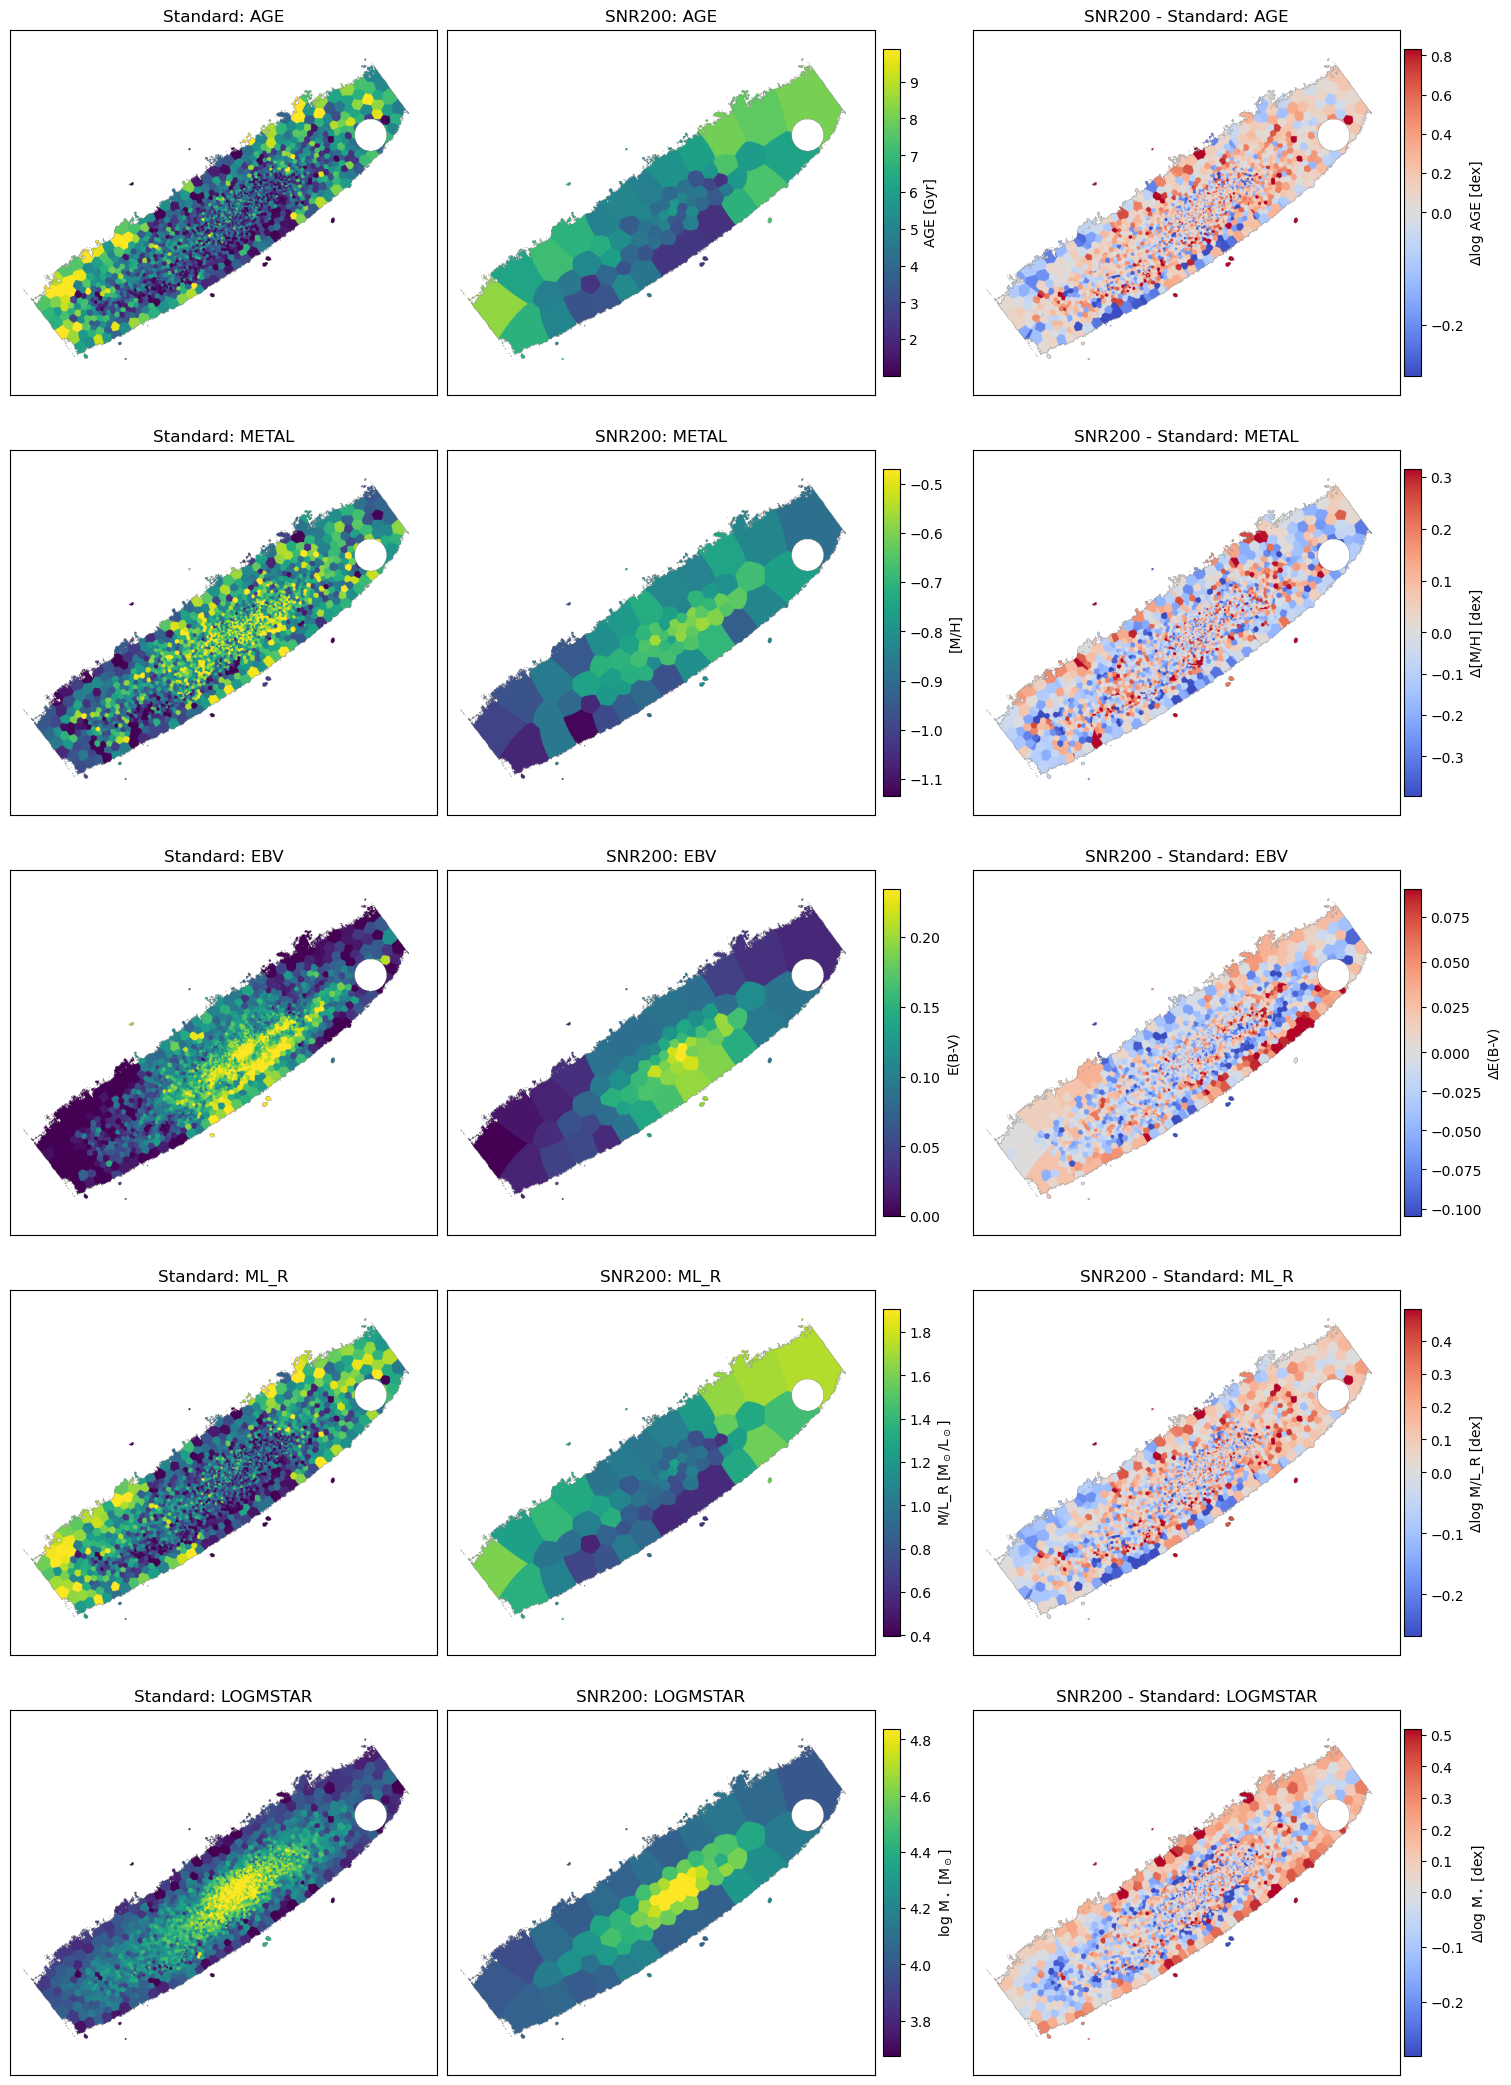

In [3]:
if 'sfh_mass_diag' not in globals():
    raise RuntimeError('Run the previous diagnostics setup cell first.')

plot_order = [
    ('AGE', 'AGE [Gyr]', 'Δlog AGE [dex]'),
    ('METAL', '[M/H]', 'Δ[M/H] [dex]'),
    ('EBV', 'E(B-V)', 'ΔE(B-V)'),
    ('ML_R', 'M/L_R [M$_\\odot$/L$_\\odot$]', 'Δlog M/L_R [dex]'),
    ('LOGMSTAR', 'log M$_\\star$ [M$_\\odot$]', 'Δlog M$_\\star$ [dex]'),
]

fig, axes = plt.subplots(len(plot_order), 3, figsize=(15, 4.2 * len(plot_order)), constrained_layout=True)

for row, (key, map_label, delta_label) in enumerate(plot_order):
    std = sfh_mass_diag[key]['std']
    snr = sfh_mass_diag[key]['snr200']
    common = np.isfinite(std) & np.isfinite(snr)
    if not np.any(common):
        for col in range(3):
            axes[row, col].text(0.5, 0.5, f'No common finite spaxels for {key}', ha='center', va='center')
            axes[row, col].axis("off")
        continue

    combined = np.concatenate([std[common], snr[common]])
    vmin, vmax = np.nanpercentile(combined, [2, 98])

    if key in {"AGE", "ML_R"}:
        delta = np.full_like(std, np.nan, dtype=float)
        ratio_mask = common & (std > 0) & (snr > 0)
        delta[ratio_mask] = np.log10(snr[ratio_mask] / std[ratio_mask])
    else:
        delta = np.where(common, snr - std, np.nan)

    delta_finite = delta[np.isfinite(delta)]
    if delta_finite.size > 0:
        dmin, dmax = np.nanpercentile(delta_finite, [2, 98])
        if dmin < 0 < dmax:
            dnorm = TwoSlopeNorm(vmin=dmin, vcenter=0.0, vmax=dmax)
        else:
            dnorm = None
    else:
        dnorm = None

    im0 = axes[row, 0].imshow(np.where(common, std, np.nan), origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
    im1 = axes[row, 1].imshow(np.where(common, snr, np.nan), origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
    im2 = axes[row, 2].imshow(delta, origin='lower', cmap='coolwarm', norm=dnorm)

    axes[row, 0].set_title(f'Standard: {key}')
    axes[row, 1].set_title(f'SNR200: {key}')
    axes[row, 2].set_title(f'SNR200 - Standard: {key}')

    for col in range(3):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

    cbar0 = fig.colorbar(im0, ax=axes[row, :2], shrink=0.8, pad=0.01)
    cbar0.set_label(map_label)
    cbar1 = fig.colorbar(im2, ax=axes[row, 2], shrink=0.8, pad=0.01)
    cbar1.set_label(delta_label)

plt.show()


Common-spaxel smoking-gun ranking (sorted by |Spearman rho| with ΔlogMSTAR):
  Δlog M/L_R [dex]     | rho= 0.5549 | median candidate delta= 0.0357 | N=155,091
  Δlog L_R proxy [dex] | rho= 0.5362 | median candidate delta= 0.0133 | N=155,091
  Δlog AGE [dex]       | rho= 0.4807 | median candidate delta= 0.0733 | N=155,091
  ΔEBV                 | rho= 0.2258 | median candidate delta= 0.0000 | N=155,091
  ΔMETAL [dex]         | rho=-0.1150 | median candidate delta=-0.0310 | N=155,091


/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


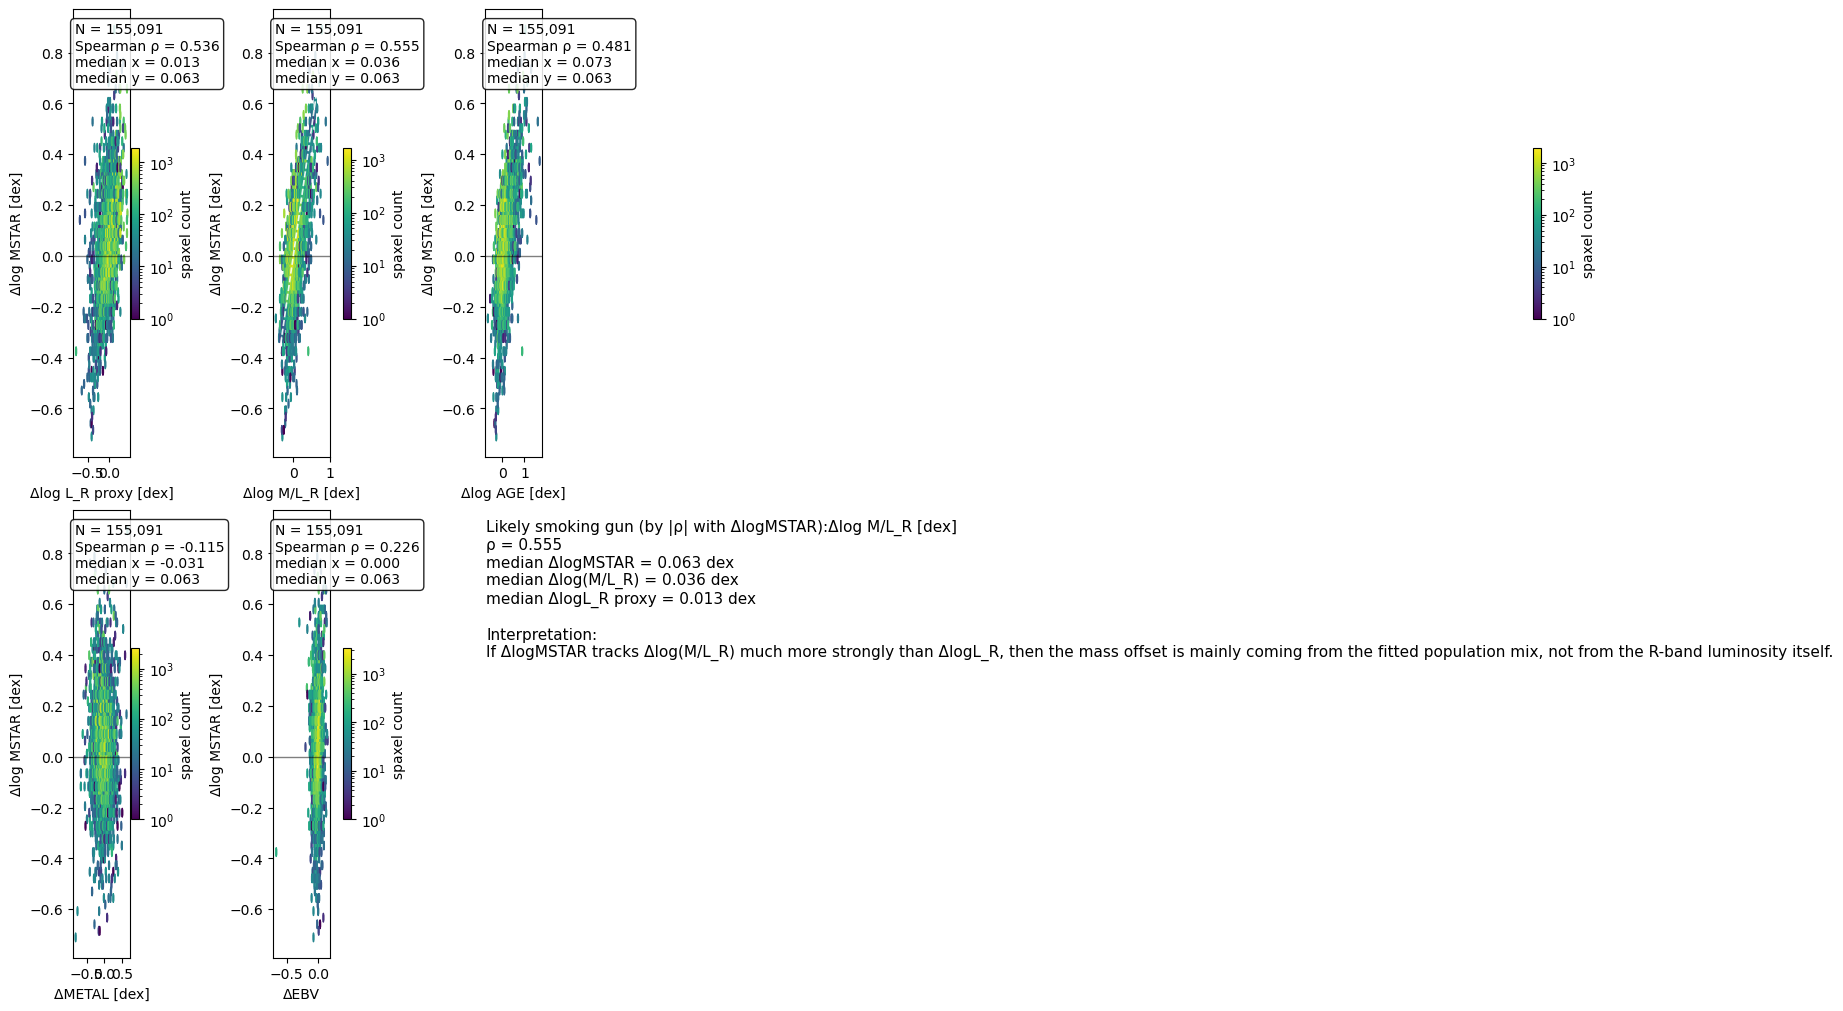

In [4]:
if 'sfh_mass_diag' not in globals():
    raise RuntimeError('Run the diagnostics setup cell first.')

age_std = sfh_mass_diag['AGE']['std']
age_snr = sfh_mass_diag['AGE']['snr200']
metal_std = sfh_mass_diag['METAL']['std']
metal_snr = sfh_mass_diag['METAL']['snr200']
ebv_std = sfh_mass_diag['EBV']['std']
ebv_snr = sfh_mass_diag['EBV']['snr200']
mlr_std = sfh_mass_diag['ML_R']['std']
mlr_snr = sfh_mass_diag['ML_R']['snr200']
logm_std = sfh_mass_diag['LOGMSTAR']['std']
logm_snr = sfh_mass_diag['LOGMSTAR']['snr200']

delta_logm = logm_snr - logm_std
delta_logmlr = np.log10(mlr_snr) - np.log10(mlr_std)
logl_std_proxy = logm_std - np.log10(mlr_std)
logl_snr_proxy = logm_snr - np.log10(mlr_snr)
delta_logl_proxy = logl_snr_proxy - logl_std_proxy
delta_logage = np.log10(age_snr) - np.log10(age_std)
delta_metal = metal_snr - metal_std
delta_ebv = ebv_snr - ebv_std

smoking_gun_candidates = [
    ('Δlog L_R proxy [dex]', delta_logl_proxy),
    ('Δlog M/L_R [dex]', delta_logmlr),
    ('Δlog AGE [dex]', delta_logage),
    ('ΔMETAL [dex]', delta_metal),
    ('ΔEBV', delta_ebv),
]

summary_rows = []
for label, x in smoking_gun_candidates:
    mask = np.isfinite(x) & np.isfinite(delta_logm)
    if np.count_nonzero(mask) < 3:
        summary_rows.append((label, np.nan, np.nan, int(np.count_nonzero(mask))))
        continue
    rho = float(spearmanr(x[mask], delta_logm[mask]).statistic)
    med = float(np.nanmedian(x[mask]))
    summary_rows.append((label, rho, med, int(np.count_nonzero(mask))))

summary_rows_sorted = sorted(summary_rows, key=lambda row: (np.nan_to_num(abs(row[1]), nan=-1.0)), reverse=True)

print("Common-spaxel smoking-gun ranking (sorted by |Spearman rho| with ΔlogMSTAR):")
for label, rho, med, n in summary_rows_sorted:
    print(f"  {label:20s} | rho={rho: .4f} | median candidate delta={med: .4f} | N={n:,}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
axes_flat = axes.ravel()

for ax, (label, x) in zip(axes_flat[:-1], smoking_gun_candidates):
    mask = np.isfinite(x) & np.isfinite(delta_logm)
    if np.count_nonzero(mask) < 3:
        ax.text(0.5, 0.5, f"Not enough valid points for {label}", ha="center", va="center")
        ax.axis("off")
        continue

    hb = ax.hexbin(x[mask], delta_logm[mask], gridsize=55, mincnt=1, bins='log', cmap='viridis')
    rho = float(spearmanr(x[mask], delta_logm[mask]).statistic)
    ax.axhline(0.0, color="black", lw=1.0, alpha=0.5)
    if 'M/L' in label:
        lo = max(np.nanmin(x[mask]), np.nanmin(delta_logm[mask]))
        hi = min(np.nanmax(x[mask]), np.nanmax(delta_logm[mask]))
        ax.plot([lo, hi], [lo, hi], color="white", lw=1.2, ls="--", alpha=0.9)
    ax.set_xlabel(label)
    ax.set_ylabel('Δlog MSTAR [dex]')
    ax.text(
        0.03, 0.97,
        f"N = {int(np.count_nonzero(mask)):,}\n"
        f"Spearman ρ = {rho:.3f}\n"
        f"median x = {np.nanmedian(x[mask]):.3f}\n"
        f"median y = {np.nanmedian(delta_logm[mask]):.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )
    fig.colorbar(hb, ax=ax, shrink=0.85, pad=0.01, label="spaxel count")

summary_ax = axes_flat[-1]
summary_ax.axis("off")
best_label, best_rho, best_med, best_n = summary_rows_sorted[0]
summary_text = [
    'Likely smoking gun (by |ρ| with ΔlogMSTAR):',
    f"{best_label}\n",
    f"ρ = {best_rho:.3f}\n",
    f"median ΔlogMSTAR = {np.nanmedian(delta_logm[np.isfinite(delta_logm)]):.3f} dex\n",
    f"median Δlog(M/L_R) = {np.nanmedian(delta_logmlr[np.isfinite(delta_logmlr)]):.3f} dex\n",
    f"median ΔlogL_R proxy = {np.nanmedian(delta_logl_proxy[np.isfinite(delta_logl_proxy)]):.3f} dex\n",
    "\nInterpretation:\n",
    "If ΔlogMSTAR tracks Δlog(M/L_R) much more strongly than ΔlogL_R, then the mass offset is mainly coming from the fitted population mix, not from the R-band luminosity itself.",
]
summary_ax.text(0.02, 0.98, "".join(summary_text), va="top", ha="left", fontsize=11)

plt.show()


## Pseudo Low-Resolution M/L Test

This test uses the standard-resolution `ML_R` map together with the standard-resolution `R`-band light map to build a pseudo-SNR200 `ML_R` map on the SNR200 binning footprint.

- `pseudo_unc`: flux-weighted average using **uncorrected** `R`-band light.
- `pseudo_corr`: flux-weighted average using **corrected** `R`-band light.
- Both are compared to the real SNR200 `ML_R` map.

If the pseudo low-res map already matches the SNR200 map well, then simple luminosity-weighted mixing is probably the main driver. If it does not, then the SNR200 SFH fit is doing something beyond a simple weighted average of the higher-resolution solution.


Pseudo low-resolution M/L test for NGC4396:
  SNR200 bins with pseudo_unc values : 71
  SNR200 bins with pseudo_corr values: 71
  Bin-level median log10(SNR200 / pseudo_unc)  : +0.0371 dex
  Bin-level Spearman rho [log pseudo_unc, log SNR200] : 0.9056
  Bin-level median log10(SNR200 / pseudo_corr) : +0.0411 dex
  Bin-level Spearman rho [log pseudo_corr, log SNR200]: 0.8967

Integrated total-mass comparison reconstructed from the maps:
  Standard resolved total mass        : 9.4535 dex
  Pseudo low-res total (unc weight)   : 9.4170 dex
  Pseudo low-res total (corr weight)  : 9.4101 dex
  Actual SNR200 total mass            : 9.4469 dex


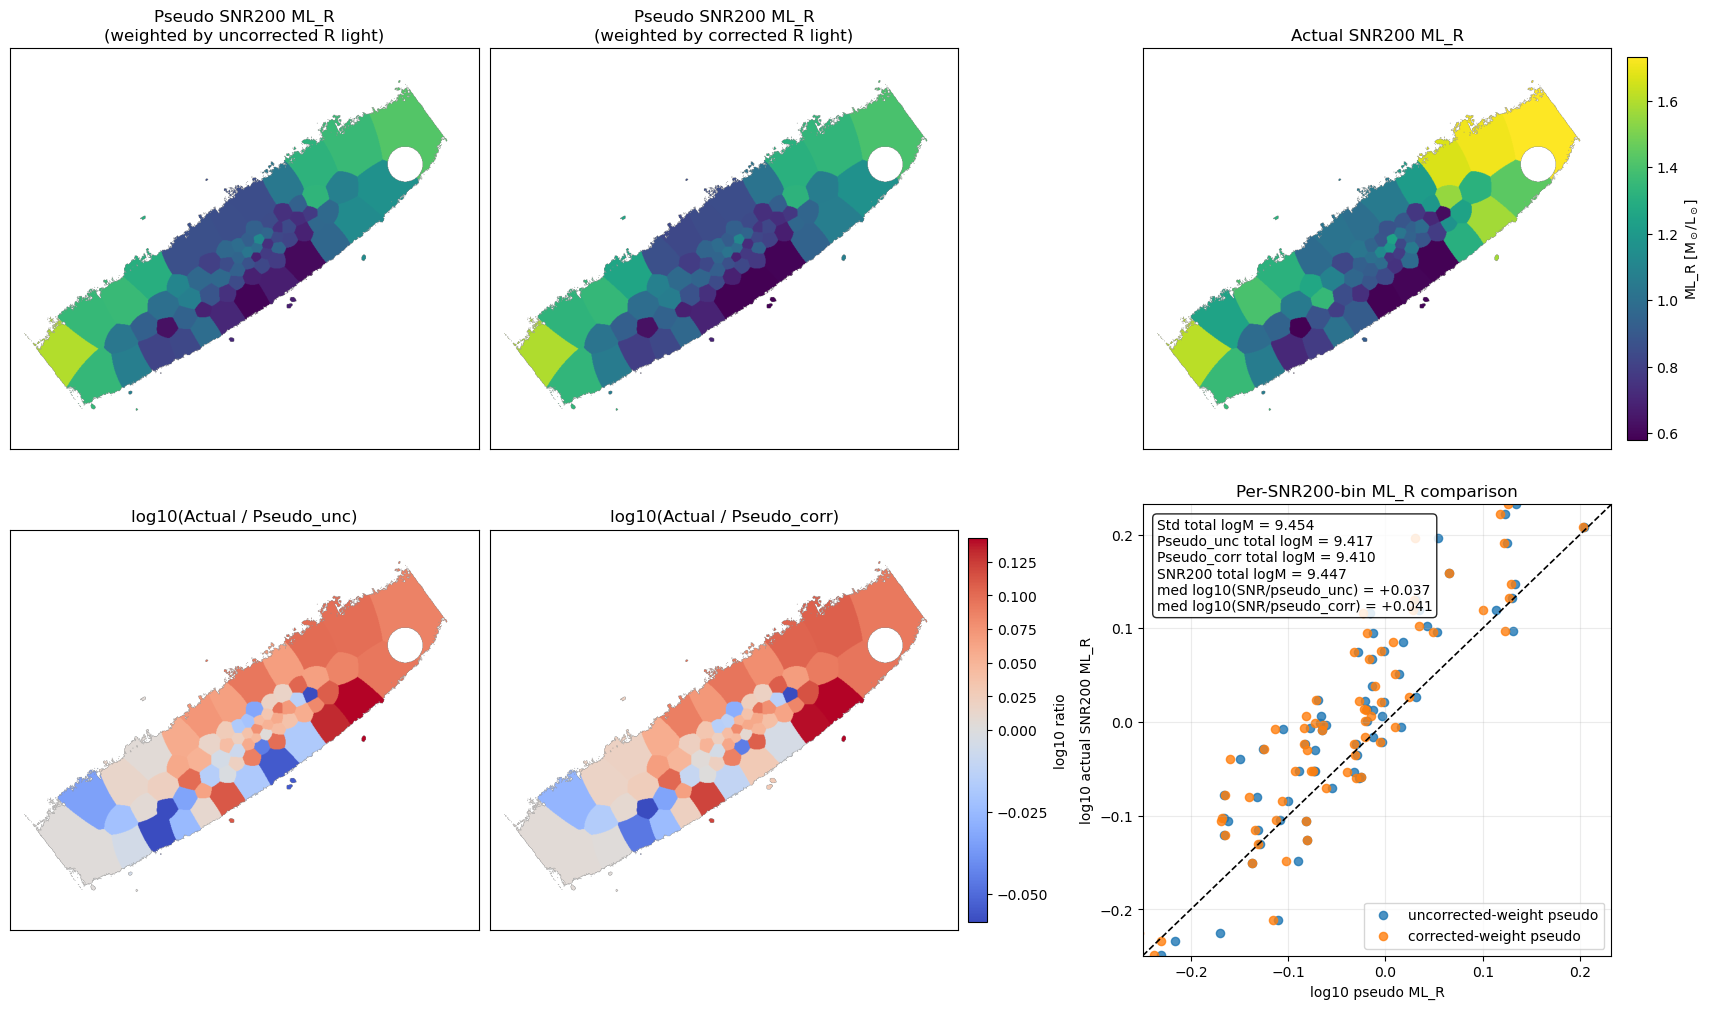

In [5]:
if 'sfh_mass_diag' not in globals():
    raise RuntimeError('Run the SFH / M-L diagnostics setup cell first.')

DIST_MPC = 16.5
M_R_SUN_AB = 4.61


def _mag_ab_to_flux_proxy(mag_ab):
    mag_ab = np.asarray(mag_ab, dtype=float)
    out = np.full_like(mag_ab, np.nan, dtype=float)
    good = np.isfinite(mag_ab)
    out[good] = 10.0 ** (-0.4 * mag_ab[good])
    return out


def _mag_ab_to_lsun(mag_ab, dist_mpc=DIST_MPC, m_sun_ab=M_R_SUN_AB):
    mag_ab = np.asarray(mag_ab, dtype=float)
    out = np.full_like(mag_ab, np.nan, dtype=float)
    good = np.isfinite(mag_ab)
    distmod = 5.0 * np.log10(dist_mpc * 1.0e6 / 10.0)
    abs_mag = mag_ab[good] - distmod
    out[good] = 10.0 ** (-0.4 * (abs_mag - m_sun_ab))
    return out


def _build_pseudo_bin_map(highres_value, highres_weight, lowres_binid, lowres_actual=None):
    highres_value = np.asarray(highres_value, dtype=float)
    highres_weight = np.asarray(highres_weight, dtype=float)
    lowres_binid = np.asarray(lowres_binid, dtype=float)
    pseudo_map = np.full_like(highres_value, np.nan, dtype=float)
    rows = []

    valid_bins = np.unique(lowres_binid[np.isfinite(lowres_binid) & (lowres_binid >= 0)]).astype(int)
    for bid in valid_bins:
        in_bin = lowres_binid == bid
        good = in_bin & np.isfinite(highres_value) & np.isfinite(highres_weight) & (highres_weight > 0)
        if not np.any(good):
            continue

        weighted_value = np.sum(highres_value[good] * highres_weight[good]) / np.sum(highres_weight[good])
        pseudo_map[in_bin] = weighted_value

        actual_value = np.nan
        if lowres_actual is not None:
            actual_good = in_bin & np.isfinite(lowres_actual)
            if np.any(actual_good):
                actual_value = float(np.nanmedian(lowres_actual[actual_good]))

        rows.append({
            'binid': int(bid),
            'pseudo': float(weighted_value),
            'actual': float(actual_value),
            'npix': int(np.count_nonzero(good)),
            'sum_weight': float(np.sum(highres_weight[good])),
        })

    return pseudo_map, rows


with fits.open(STANDARD_EXT_FILE) as hdul_std_ext, fits.open(SNR200_EXT_FILE) as hdul_snr_ext:
    mlr_std = _get_map(hdul_std_ext, 'ML_R')
    mlr_snr = _get_map(hdul_snr_ext, 'ML_R')
    logm_std = _get_map(hdul_std_ext, 'LOGMSTAR')
    logm_snr = _get_map(hdul_snr_ext, 'LOGMSTAR')
    binid_snr = _get_map(hdul_snr_ext, 'BINID')
    mag_unc_std = _get_map(hdul_std_ext, 'MAGNITUDE_R_UNCORRECTED', 'magnitude_r_uncorrected')
    mag_corr_std = _get_map(hdul_std_ext, 'MAGNITUDE_R', 'magnitude_r')
    mag_corr_snr = _get_map(hdul_snr_ext, 'MAGNITUDE_R', 'magnitude_r')
    flux_corr_std = _get_map(hdul_std_ext, 'FLUX_R_CORR', 'FLUX_R_corr')

rflux_unc_std = _mag_ab_to_flux_proxy(mag_unc_std)
rflux_corr_std = np.where(np.isfinite(flux_corr_std) & (flux_corr_std > 0), flux_corr_std, np.nan)
lcorr_std = _mag_ab_to_lsun(mag_corr_std)
lcorr_snr = _mag_ab_to_lsun(mag_corr_snr)

pseudo_mlr_unc, rows_unc = _build_pseudo_bin_map(mlr_std, rflux_unc_std, binid_snr, lowres_actual=mlr_snr)
pseudo_mlr_corr, rows_corr = _build_pseudo_bin_map(mlr_std, rflux_corr_std, binid_snr, lowres_actual=mlr_snr)

bin_actual_unc = np.array([row["actual"] for row in rows_unc], dtype=float)
bin_pseudo_unc = np.array([row["pseudo"] for row in rows_unc], dtype=float)
bin_actual_corr = np.array([row["actual"] for row in rows_corr], dtype=float)
bin_pseudo_corr = np.array([row["pseudo"] for row in rows_corr], dtype=float)

mask_unc = np.isfinite(bin_actual_unc) & np.isfinite(bin_pseudo_unc) & (bin_actual_unc > 0) & (bin_pseudo_unc > 0)
mask_corr = np.isfinite(bin_actual_corr) & np.isfinite(bin_pseudo_corr) & (bin_actual_corr > 0) & (bin_pseudo_corr > 0)

delta_log_unc = np.full_like(mlr_snr, np.nan, dtype=float)
good_unc = np.isfinite(mlr_snr) & np.isfinite(pseudo_mlr_unc) & (mlr_snr > 0) & (pseudo_mlr_unc > 0)
delta_log_unc[good_unc] = np.log10(mlr_snr[good_unc] / pseudo_mlr_unc[good_unc])

delta_log_corr = np.full_like(mlr_snr, np.nan, dtype=float)
good_corr = np.isfinite(mlr_snr) & np.isfinite(pseudo_mlr_corr) & (mlr_snr > 0) & (pseudo_mlr_corr > 0)
delta_log_corr[good_corr] = np.log10(mlr_snr[good_corr] / pseudo_mlr_corr[good_corr])

standard_total_mass = np.nansum(np.where(np.isfinite(lcorr_std) & np.isfinite(mlr_std), lcorr_std * mlr_std, np.nan))
pseudo_total_mass_unc = np.nansum(np.where(np.isfinite(lcorr_std) & np.isfinite(pseudo_mlr_unc), lcorr_std * pseudo_mlr_unc, np.nan))
pseudo_total_mass_corr = np.nansum(np.where(np.isfinite(lcorr_std) & np.isfinite(pseudo_mlr_corr), lcorr_std * pseudo_mlr_corr, np.nan))
snr200_total_mass = np.nansum(np.where(np.isfinite(lcorr_snr) & np.isfinite(mlr_snr), lcorr_snr * mlr_snr, np.nan))

print("Pseudo low-resolution M/L test for NGC4396:")
print(f"  SNR200 bins with pseudo_unc values : {int(np.count_nonzero(mask_unc))}")
print(f"  SNR200 bins with pseudo_corr values: {int(np.count_nonzero(mask_corr))}")
if np.any(mask_unc):
    rho_unc = float(spearmanr(np.log10(bin_pseudo_unc[mask_unc]), np.log10(bin_actual_unc[mask_unc])).statistic)
    med_unc = float(np.nanmedian(np.log10(bin_actual_unc[mask_unc] / bin_pseudo_unc[mask_unc])))
    print(f"  Bin-level median log10(SNR200 / pseudo_unc)  : {med_unc:+.4f} dex")
    print(f"  Bin-level Spearman rho [log pseudo_unc, log SNR200] : {rho_unc:.4f}")
if np.any(mask_corr):
    rho_corr = float(spearmanr(np.log10(bin_pseudo_corr[mask_corr]), np.log10(bin_actual_corr[mask_corr])).statistic)
    med_corr = float(np.nanmedian(np.log10(bin_actual_corr[mask_corr] / bin_pseudo_corr[mask_corr])))
    print(f"  Bin-level median log10(SNR200 / pseudo_corr) : {med_corr:+.4f} dex")
    print(f"  Bin-level Spearman rho [log pseudo_corr, log SNR200]: {rho_corr:.4f}")

print("\nIntegrated total-mass comparison reconstructed from the maps:")
print(f"  Standard resolved total mass        : {np.log10(standard_total_mass):.4f} dex")
print(f"  Pseudo low-res total (unc weight)   : {np.log10(pseudo_total_mass_unc):.4f} dex")
print(f"  Pseudo low-res total (corr weight)  : {np.log10(pseudo_total_mass_corr):.4f} dex")
print(f"  Actual SNR200 total mass            : {np.log10(snr200_total_mass):.4f} dex")

pseudo_lowres_test = {
    'pseudo_mlr_unc': pseudo_mlr_unc,
    'pseudo_mlr_corr': pseudo_mlr_corr,
    'delta_log_unc': delta_log_unc,
    'delta_log_corr': delta_log_corr,
    'bin_rows_unc': rows_unc,
    'bin_rows_corr': rows_corr,
    'standard_total_mass': standard_total_mass,
    'pseudo_total_mass_unc': pseudo_total_mass_unc,
    'pseudo_total_mass_corr': pseudo_total_mass_corr,
    'snr200_total_mass': snr200_total_mass,
}

combined = np.concatenate([
    pseudo_mlr_unc[np.isfinite(pseudo_mlr_unc)],
    pseudo_mlr_corr[np.isfinite(pseudo_mlr_corr)],
    mlr_snr[np.isfinite(mlr_snr)],
])
vmin, vmax = np.nanpercentile(combined, [2, 98])

delta_all = np.concatenate([delta_log_unc[np.isfinite(delta_log_unc)], delta_log_corr[np.isfinite(delta_log_corr)]])
dmin, dmax = np.nanpercentile(delta_all, [2, 98])
dnorm = TwoSlopeNorm(vmin=dmin, vcenter=0.0, vmax=dmax) if dmin < 0 < dmax else None

fig, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)

im0 = axes[0, 0].imshow(pseudo_mlr_unc, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
im1 = axes[0, 1].imshow(pseudo_mlr_corr, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
im2 = axes[0, 2].imshow(mlr_snr, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
im3 = axes[1, 0].imshow(delta_log_unc, origin='lower', cmap='coolwarm', norm=dnorm)
im4 = axes[1, 1].imshow(delta_log_corr, origin='lower', cmap='coolwarm', norm=dnorm)

axes[0, 0].set_title('Pseudo SNR200 ML_R\n(weighted by uncorrected R light)')
axes[0, 1].set_title('Pseudo SNR200 ML_R\n(weighted by corrected R light)')
axes[0, 2].set_title('Actual SNR200 ML_R')
axes[1, 0].set_title('log10(Actual / Pseudo_unc)')
axes[1, 1].set_title('log10(Actual / Pseudo_corr)')

for ax in axes[:, :2].ravel().tolist() + [axes[0, 2]]:
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im0, ax=axes[0, :], shrink=0.85, pad=0.01, label="ML_R [M$_\\odot$/L$_\\odot$]")
fig.colorbar(im3, ax=axes[1, :2], shrink=0.85, pad=0.01, label="log10 ratio")

scatter_ax = axes[1, 2]
scatter_ax.set_title("Per-SNR200-bin ML_R comparison")
if np.any(mask_unc):
    scatter_ax.scatter(np.log10(bin_pseudo_unc[mask_unc]), np.log10(bin_actual_unc[mask_unc]), s=35, alpha=0.8, label="uncorrected-weight pseudo")
if np.any(mask_corr):
    scatter_ax.scatter(np.log10(bin_pseudo_corr[mask_corr]), np.log10(bin_actual_corr[mask_corr]), s=35, alpha=0.8, label="corrected-weight pseudo")
xy = np.concatenate([
    np.log10(bin_pseudo_unc[mask_unc]) if np.any(mask_unc) else np.array([]),
    np.log10(bin_pseudo_corr[mask_corr]) if np.any(mask_corr) else np.array([]),
    np.log10(bin_actual_unc[mask_unc]) if np.any(mask_unc) else np.array([]),
    np.log10(bin_actual_corr[mask_corr]) if np.any(mask_corr) else np.array([]),
])
if xy.size > 0:
    lo, hi = np.nanpercentile(xy, [1, 99])
    scatter_ax.plot([lo, hi], [lo, hi], color="black", lw=1.2, ls="--")
    scatter_ax.set_xlim(lo, hi)
    scatter_ax.set_ylim(lo, hi)
scatter_ax.set_xlabel("log10 pseudo ML_R")
scatter_ax.set_ylabel("log10 actual SNR200 ML_R")
scatter_ax.legend(loc="lower right")
scatter_ax.grid(alpha=0.25)

summary_lines = [
    f"Std total logM = {np.log10(standard_total_mass):.3f}",
    f"Pseudo_unc total logM = {np.log10(pseudo_total_mass_unc):.3f}",
    f"Pseudo_corr total logM = {np.log10(pseudo_total_mass_corr):.3f}",
    f"SNR200 total logM = {np.log10(snr200_total_mass):.3f}",
]
if np.any(mask_unc):
    summary_lines.append(f"med log10(SNR/pseudo_unc) = {np.nanmedian(np.log10(bin_actual_unc[mask_unc] / bin_pseudo_unc[mask_unc])):+.3f}")
if np.any(mask_corr):
    summary_lines.append(f"med log10(SNR/pseudo_corr) = {np.nanmedian(np.log10(bin_actual_corr[mask_corr] / bin_pseudo_corr[mask_corr])):+.3f}")
scatter_ax.text(0.03, 0.97, "\n".join(summary_lines), transform=scatter_ax.transAxes, va="top", ha="left", fontsize=10, bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

plt.show()


## Pseudo Low-Resolution M/L Test: Self-Weighted `ML_R`

This is a more aggressive stress test: instead of weighting the standard-resolution `ML_R` map by `R`-band light, this cell weights it by `ML_R` itself.

Inside each SNR200 bin, the pseudo value is:

`pseudo_mlr_self = sum(ML_R * ML_R) / sum(ML_R) = sum(ML_R^2) / sum(ML_R)`

So this is not a physical flux weighting. It is just a way to test whether letting intrinsically high-`ML_R` spaxels dominate the average can reproduce the SNR200 enhancement.


Pseudo low-resolution self-weighted ML_R test for NGC4396:
  Definition: pseudo = sum(ML_R^2) / sum(ML_R) within each SNR200 bin
  SNR200 bins with pseudo_self values: 71
  Bin-level median log10(SNR200 / pseudo_self): -0.0136 dex
  Bin-level Spearman rho [log pseudo_self, log SNR200]: 0.8046

Integrated total-mass comparison reconstructed from the maps:
  Standard resolved total mass      : 9.4535 dex
  Pseudo self-weighted total mass   : 9.4737 dex
  Actual SNR200 total mass          : 9.4469 dex


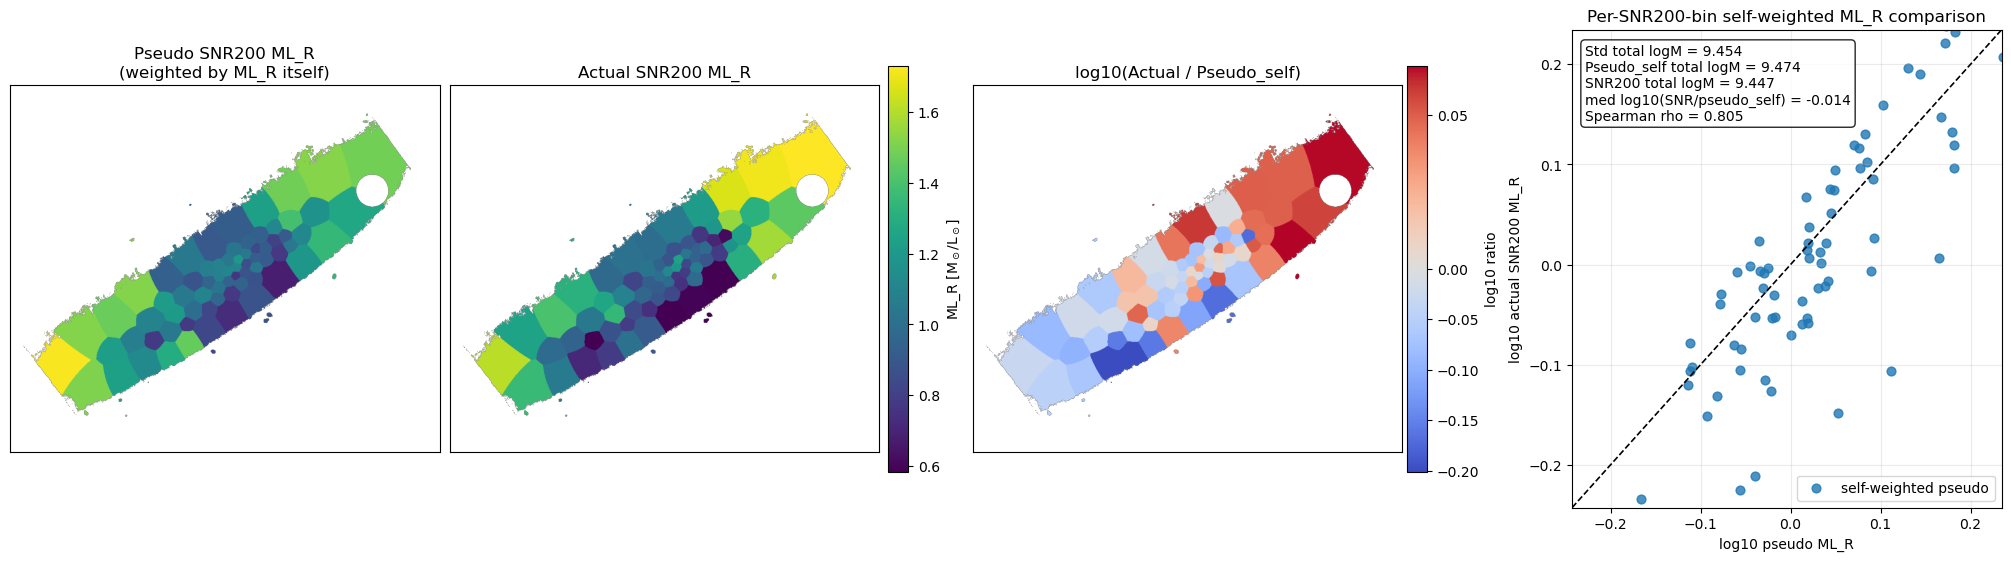

In [6]:
if 'sfh_mass_diag' not in globals() or '_build_pseudo_bin_map' not in globals():
    raise RuntimeError('Run the setup cell and the previous pseudo low-resolution M/L test cell first.')

DIST_MPC_SELF = 16.5
M_R_SUN_AB_SELF = 4.61


def _mag_ab_to_lsun_self(mag_ab, dist_mpc=DIST_MPC_SELF, m_sun_ab=M_R_SUN_AB_SELF):
    mag_ab = np.asarray(mag_ab, dtype=float)
    out = np.full_like(mag_ab, np.nan, dtype=float)
    good = np.isfinite(mag_ab)
    distmod = 5.0 * np.log10(dist_mpc * 1.0e6 / 10.0)
    abs_mag = mag_ab[good] - distmod
    out[good] = 10.0 ** (-0.4 * (abs_mag - m_sun_ab))
    return out


with fits.open(STANDARD_EXT_FILE) as hdul_std_ext, fits.open(SNR200_EXT_FILE) as hdul_snr_ext:
    mlr_std = _get_map(hdul_std_ext, 'ML_R')
    mlr_snr = _get_map(hdul_snr_ext, 'ML_R')
    binid_snr = _get_map(hdul_snr_ext, 'BINID')
    mag_corr_std = _get_map(hdul_std_ext, 'MAGNITUDE_R', 'magnitude_r')
    mag_corr_snr = _get_map(hdul_snr_ext, 'MAGNITUDE_R', 'magnitude_r')

mlr_weight_std = np.where(np.isfinite(mlr_std) & (mlr_std > 0), mlr_std, np.nan)
pseudo_mlr_self, rows_self = _build_pseudo_bin_map(mlr_std, mlr_weight_std, binid_snr, lowres_actual=mlr_snr)

bin_actual_self = np.array([row['actual'] for row in rows_self], dtype=float)
bin_pseudo_self = np.array([row['pseudo'] for row in rows_self], dtype=float)
mask_self = np.isfinite(bin_actual_self) & np.isfinite(bin_pseudo_self) & (bin_actual_self > 0) & (bin_pseudo_self > 0)

delta_log_self = np.full_like(mlr_snr, np.nan, dtype=float)
good_self = np.isfinite(mlr_snr) & np.isfinite(pseudo_mlr_self) & (mlr_snr > 0) & (pseudo_mlr_self > 0)
delta_log_self[good_self] = np.log10(mlr_snr[good_self] / pseudo_mlr_self[good_self])

lcorr_std = _mag_ab_to_lsun_self(mag_corr_std)
lcorr_snr = _mag_ab_to_lsun_self(mag_corr_snr)
standard_total_mass = np.nansum(np.where(np.isfinite(lcorr_std) & np.isfinite(mlr_std), lcorr_std * mlr_std, np.nan))
pseudo_self_total_mass = np.nansum(np.where(np.isfinite(lcorr_std) & np.isfinite(pseudo_mlr_self), lcorr_std * pseudo_mlr_self, np.nan))
snr200_total_mass = np.nansum(np.where(np.isfinite(lcorr_snr) & np.isfinite(mlr_snr), lcorr_snr * mlr_snr, np.nan))

print('Pseudo low-resolution self-weighted ML_R test for NGC4396:')
print('  Definition: pseudo = sum(ML_R^2) / sum(ML_R) within each SNR200 bin')
print(f'  SNR200 bins with pseudo_self values: {int(np.count_nonzero(mask_self))}')
if np.any(mask_self):
    rho_self = float(spearmanr(np.log10(bin_pseudo_self[mask_self]), np.log10(bin_actual_self[mask_self])).statistic)
    med_self = float(np.nanmedian(np.log10(bin_actual_self[mask_self] / bin_pseudo_self[mask_self])))
    print(f'  Bin-level median log10(SNR200 / pseudo_self): {med_self:+.4f} dex')
    print(f'  Bin-level Spearman rho [log pseudo_self, log SNR200]: {rho_self:.4f}')

print('\nIntegrated total-mass comparison reconstructed from the maps:')
print(f'  Standard resolved total mass      : {np.log10(standard_total_mass):.4f} dex')
print(f'  Pseudo self-weighted total mass   : {np.log10(pseudo_self_total_mass):.4f} dex')
print(f'  Actual SNR200 total mass          : {np.log10(snr200_total_mass):.4f} dex')

pseudo_mlr_self_test = {
    'pseudo_mlr_self': pseudo_mlr_self,
    'delta_log_self': delta_log_self,
    'bin_rows_self': rows_self,
    'standard_total_mass': standard_total_mass,
    'pseudo_self_total_mass': pseudo_self_total_mass,
    'snr200_total_mass': snr200_total_mass,
}

combined = np.concatenate([
    pseudo_mlr_self[np.isfinite(pseudo_mlr_self)],
    mlr_snr[np.isfinite(mlr_snr)],
])
vmin, vmax = np.nanpercentile(combined, [2, 98])

delta_finite = delta_log_self[np.isfinite(delta_log_self)]
dmin, dmax = np.nanpercentile(delta_finite, [2, 98])
dnorm = TwoSlopeNorm(vmin=dmin, vcenter=0.0, vmax=dmax) if dmin < 0 < dmax else None

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5), constrained_layout=True)

im0 = axes[0].imshow(pseudo_mlr_self, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
im1 = axes[1].imshow(mlr_snr, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
im2 = axes[2].imshow(delta_log_self, origin='lower', cmap='coolwarm', norm=dnorm)

axes[0].set_title('Pseudo SNR200 ML_R\n(weighted by ML_R itself)')
axes[1].set_title('Actual SNR200 ML_R')
axes[2].set_title('log10(Actual / Pseudo_self)')

for ax in axes[:3]:
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im0, ax=axes[:2], shrink=0.85, pad=0.01, label='ML_R [M$_\\odot$/L$_\\odot$]')
fig.colorbar(im2, ax=axes[2], shrink=0.85, pad=0.01, label='log10 ratio')

scatter_ax = axes[3]
scatter_ax.set_title('Per-SNR200-bin self-weighted ML_R comparison')
if np.any(mask_self):
    scatter_ax.scatter(np.log10(bin_pseudo_self[mask_self]), np.log10(bin_actual_self[mask_self]), s=40, alpha=0.8, label='self-weighted pseudo')
    xy = np.concatenate([np.log10(bin_pseudo_self[mask_self]), np.log10(bin_actual_self[mask_self])])
    lo, hi = np.nanpercentile(xy, [1, 99])
    scatter_ax.plot([lo, hi], [lo, hi], color='black', lw=1.2, ls='--')
    scatter_ax.set_xlim(lo, hi)
    scatter_ax.set_ylim(lo, hi)
scatter_ax.set_xlabel('log10 pseudo ML_R')
scatter_ax.set_ylabel('log10 actual SNR200 ML_R')
scatter_ax.grid(alpha=0.25)
scatter_ax.legend(loc='lower right')

summary_lines = [
    f'Std total logM = {np.log10(standard_total_mass):.3f}',
    f'Pseudo_self total logM = {np.log10(pseudo_self_total_mass):.3f}',
    f'SNR200 total logM = {np.log10(snr200_total_mass):.3f}',
]
if np.any(mask_self):
    summary_lines.append(f'med log10(SNR/pseudo_self) = {np.nanmedian(np.log10(bin_actual_self[mask_self] / bin_pseudo_self[mask_self])):+.3f}')
    summary_lines.append(f'Spearman rho = {rho_self:.3f}')
scatter_ax.text(0.03, 0.97, '\n'.join(summary_lines), transform=scatter_ax.transAxes, va='top', ha='left', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.show()
